In [21]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

sns.set_theme()
warnings.filterwarnings('ignore')

In [2]:
problems = ["chemical_1_tower", "chemical_2_competition", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "nikuradse_1", "nikuradse_2", "flow_stress_phip0.1", ]

In [7]:
dfs = []
for problem in problems:
    for seed in range(10):
        if os.path.exists(f"../results/GP_{problem}_{seed}.pickle"):
            tmp_df = pd.read_csv(f"../results/GP_{problem}_{seed}.csv")
            tmp_df["run"] = seed
            tmp_df["algorithm"] = "JaxGP"
            tmp_df["dataset"] = problem
            tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
            dfs.append(tmp_df)
        else:
            missing = missing + 1
df = pd.concat(dfs, ignore_index=True)
df["r2_test"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,run,algorithm,dataset,total_time,r2_test
0,0,-0.943658,0.000000,-1.0098057,0,JaxGP,chemical_1_tower,0,-1.009806
1,1,-0.694493,20.506563,[-0.988152],0,JaxGP,chemical_1_tower,20,-0.988152
2,2,0.282013,9.692096,[0.28767782],0,JaxGP,chemical_1_tower,30,0.287678
3,3,0.283639,9.687017,[0.28767782],0,JaxGP,chemical_1_tower,39,0.287678
4,4,0.296829,9.840817,[0.35737818],0,JaxGP,chemical_1_tower,49,0.357378


In [14]:
baselines = pd.read_csv("baselines.csv")[["run", "algorithm", "dataset", "r2_test"]]
baselines = baselines[baselines["dataset"].isin(problems)]
baseline_algos = ["Operon", "QLattice", "PySR", "eggp"]
baselines = baselines[baselines["algorithm"].isin(baseline_algos)]
baselines.head()

,run,algorithm,dataset,r2_test
4696,0,eggp,chemical_1_tower,0.876939
4697,1,eggp,chemical_1_tower,0.857567
4698,2,eggp,chemical_1_tower,0.868668
4699,3,eggp,chemical_1_tower,0.829023
4700,4,eggp,chemical_1_tower,0.840139


In [15]:
max_iter = df.groupby(["dataset"])["iteration"].transform("max")
final_df = df[df["iteration"] == max_iter].reset_index(drop=True)[["run", "algorithm", "dataset", "r2_test"]]
final_df.head()

,run,algorithm,dataset,r2_test
0,0,JaxGP,chemical_1_tower,0.492187
1,1,JaxGP,chemical_1_tower,0.519054
2,2,JaxGP,chemical_1_tower,0.496462
3,3,JaxGP,chemical_1_tower,0.592214
4,4,JaxGP,chemical_1_tower,0.453226


In [16]:
merge_df = pd.concat([final_df, baselines], ignore_index=True)
merge_df.head()

,run,algorithm,dataset,r2_test
0,0,JaxGP,chemical_1_tower,0.492187
1,1,JaxGP,chemical_1_tower,0.519054
2,2,JaxGP,chemical_1_tower,0.496462
3,3,JaxGP,chemical_1_tower,0.592214
4,4,JaxGP,chemical_1_tower,0.453226


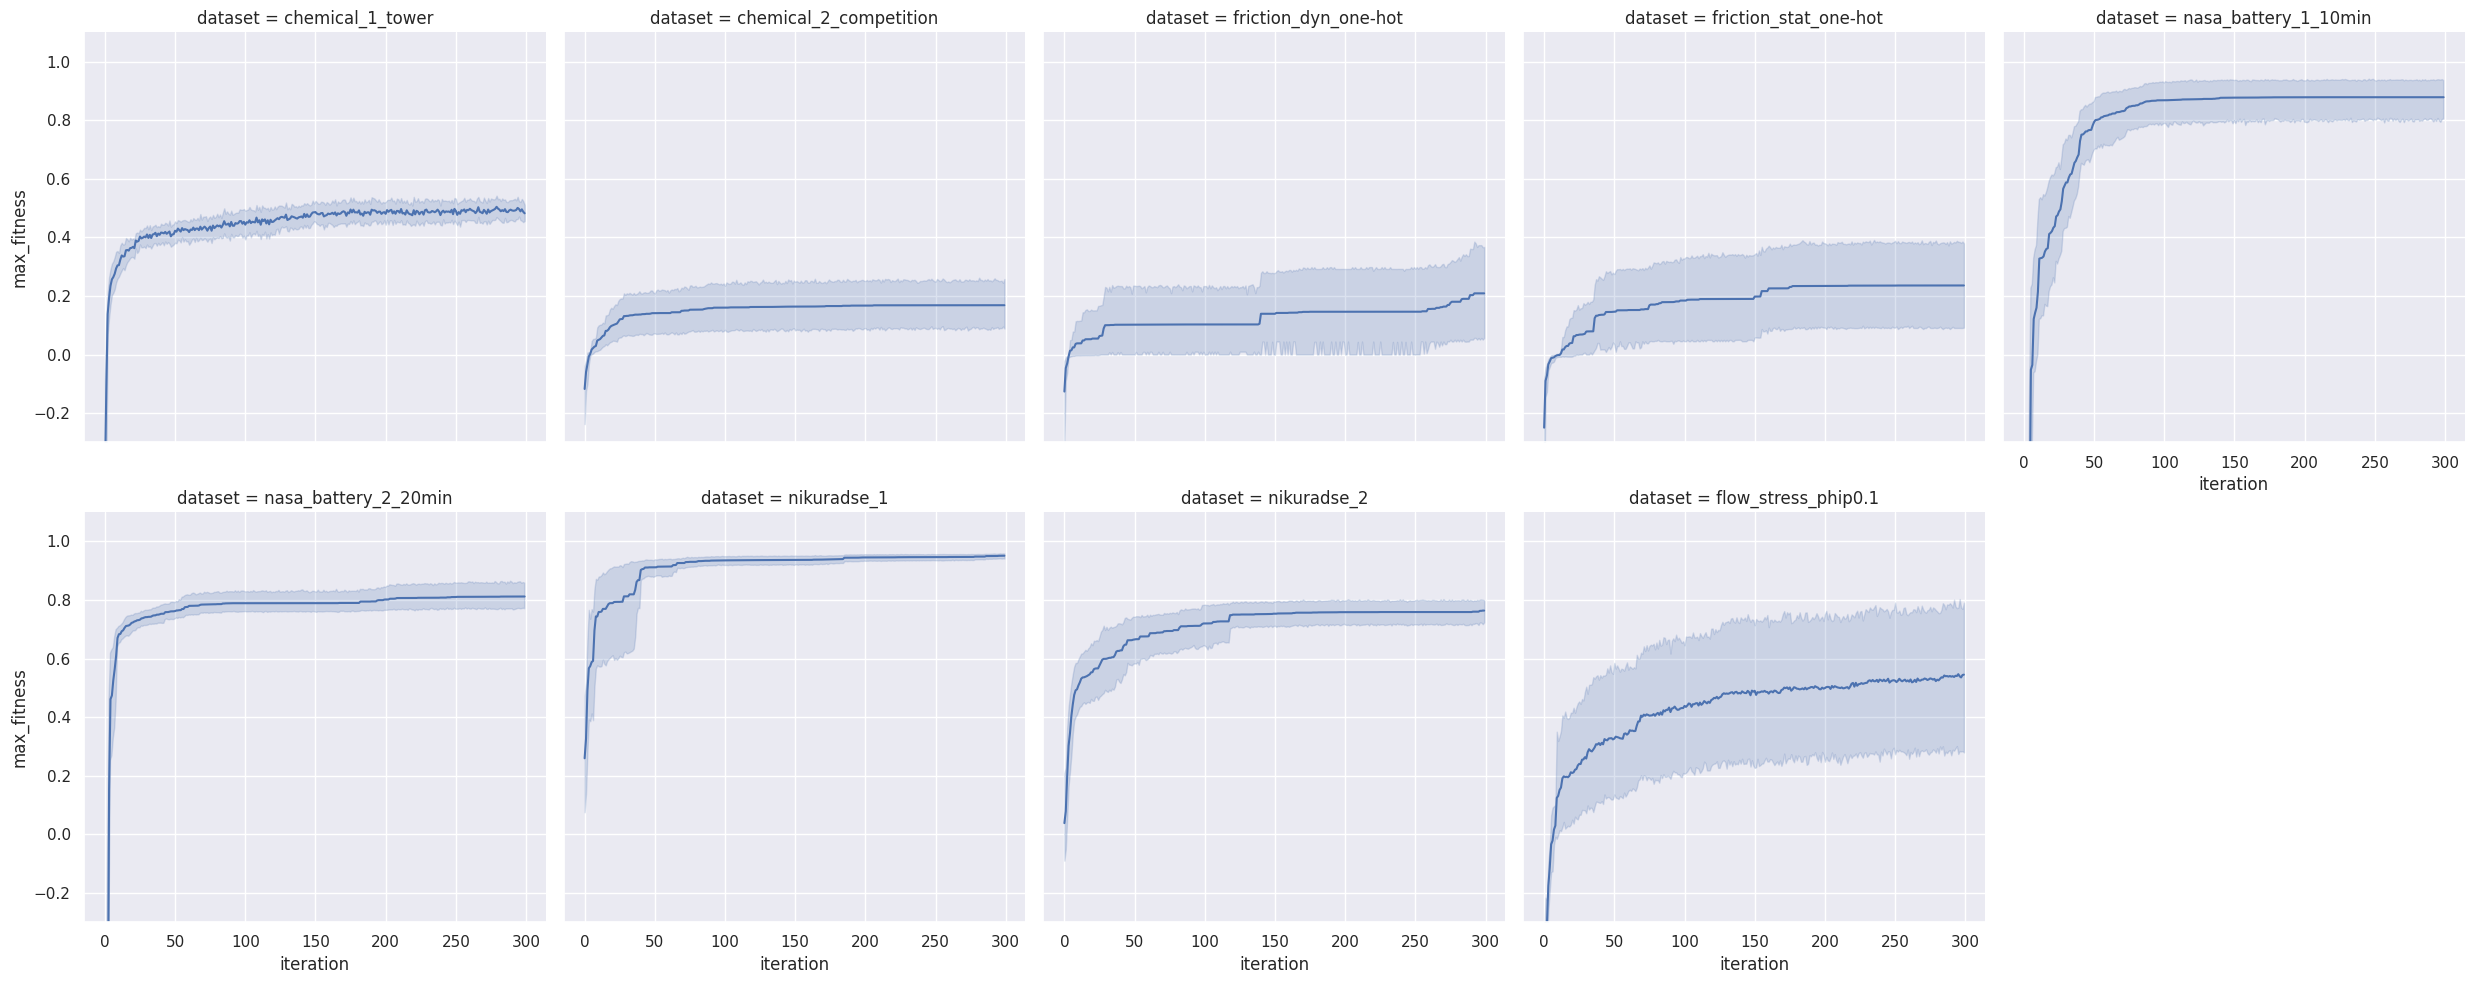

In [27]:
sns.relplot(df, x="iteration", y="max_fitness", col="dataset", col_wrap=5, kind="line")
plt.ylim(-.3, 1.1)
plt.show()

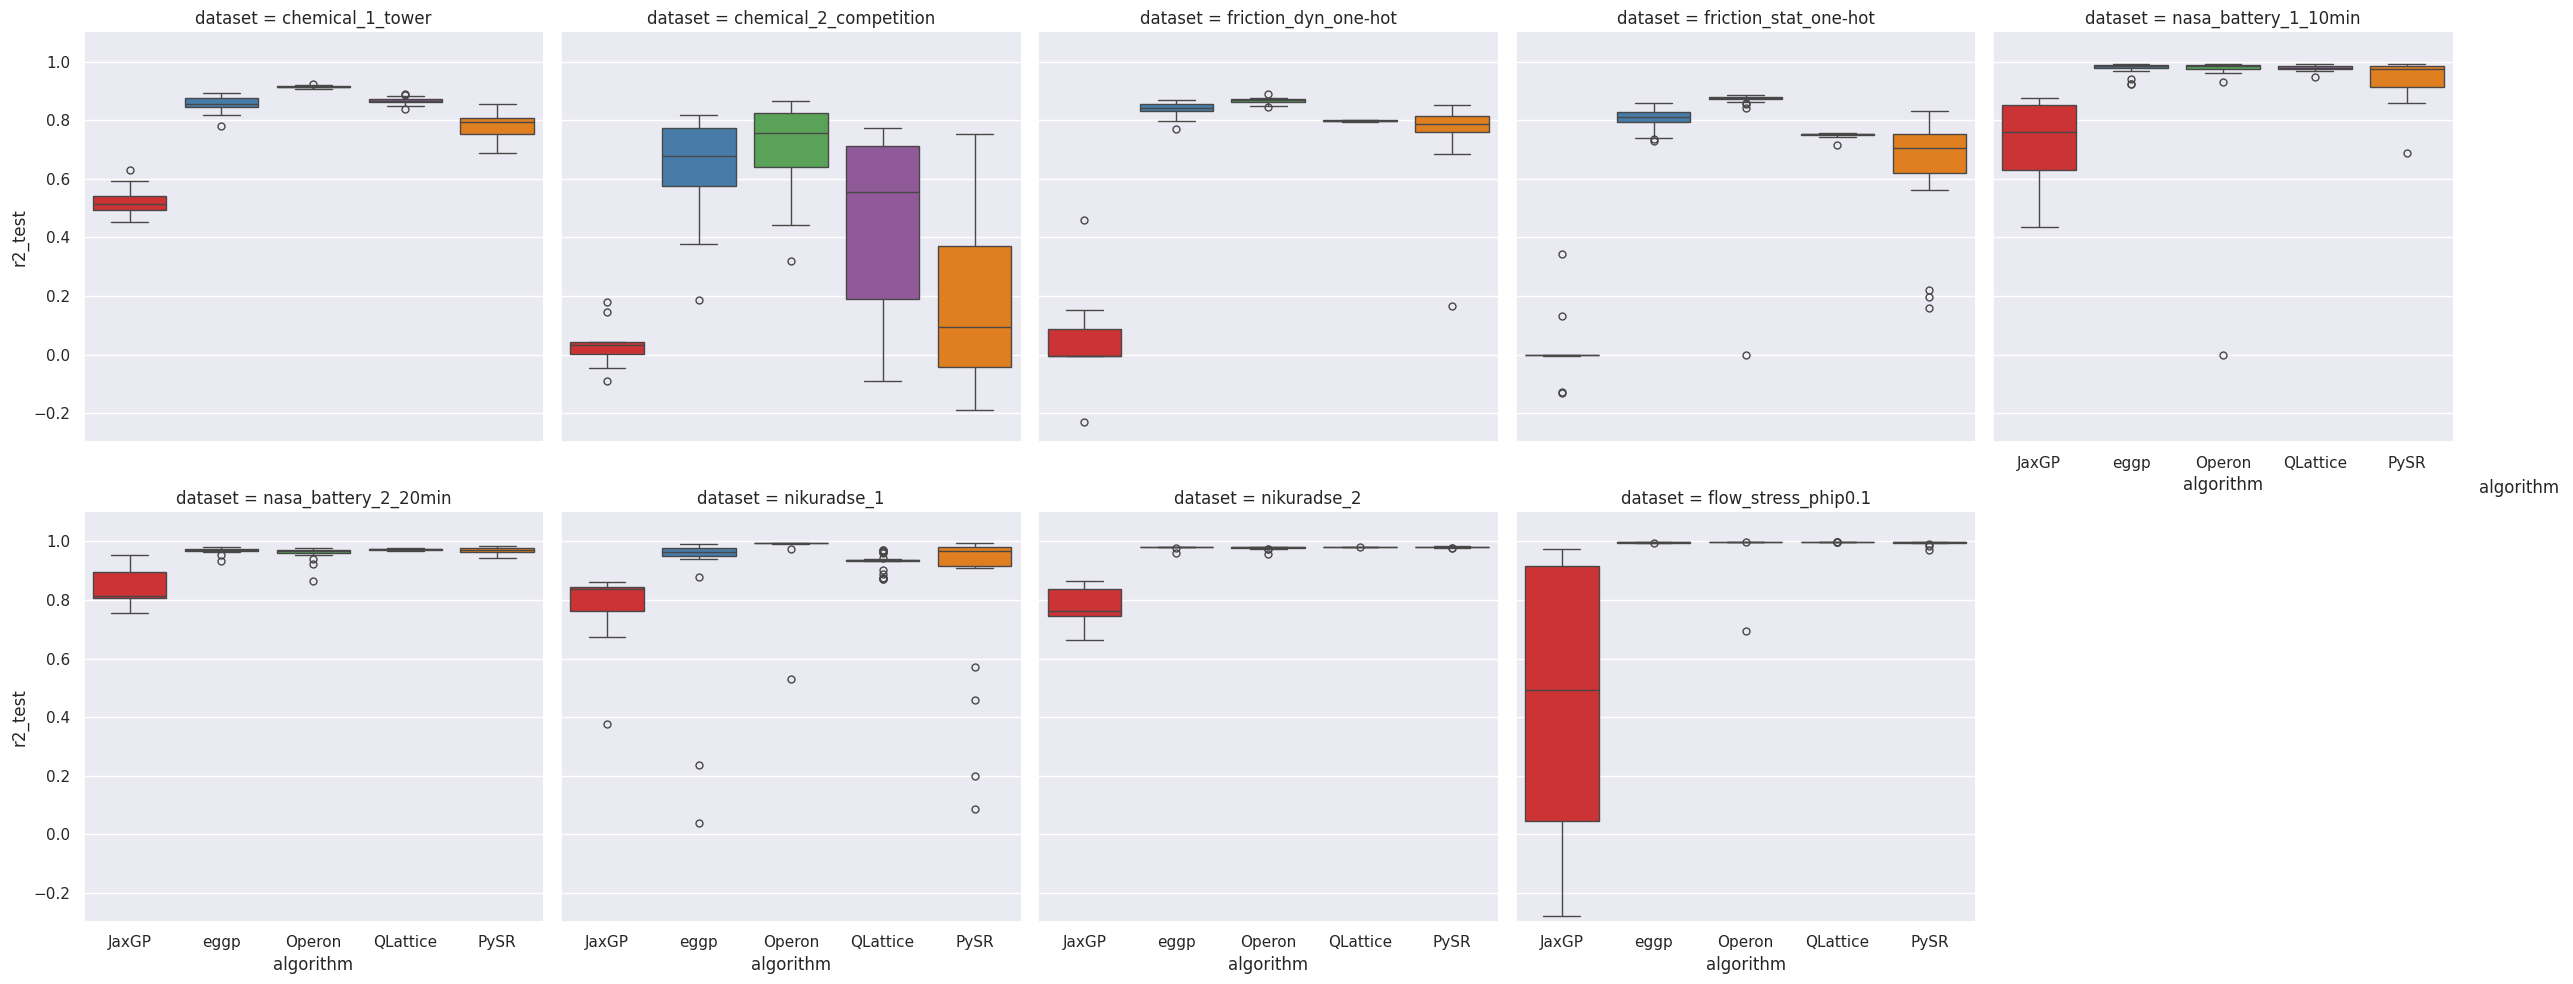

In [22]:
sns.catplot(x="algorithm", y="r2_test", hue="algorithm", data=merge_df, col_wrap=5,  # row="when",
            col="dataset", kind="box", palette="Set1")
plt.ylim(-.3, 1.1)
plt.show()